In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(df.shape)
print(df.head())


(1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLeve

In [4]:
print(df['Attrition'].value_counts())
print()
print(df['Attrition'].value_counts(normalize=True).round(2))

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     0.84
Yes    0.16
Name: proportion, dtype: float64


In [5]:
print(df.isnull().sum().sum())
print(df.dtypes.value_counts())

0
int64     26
object     9
Name: count, dtype: int64


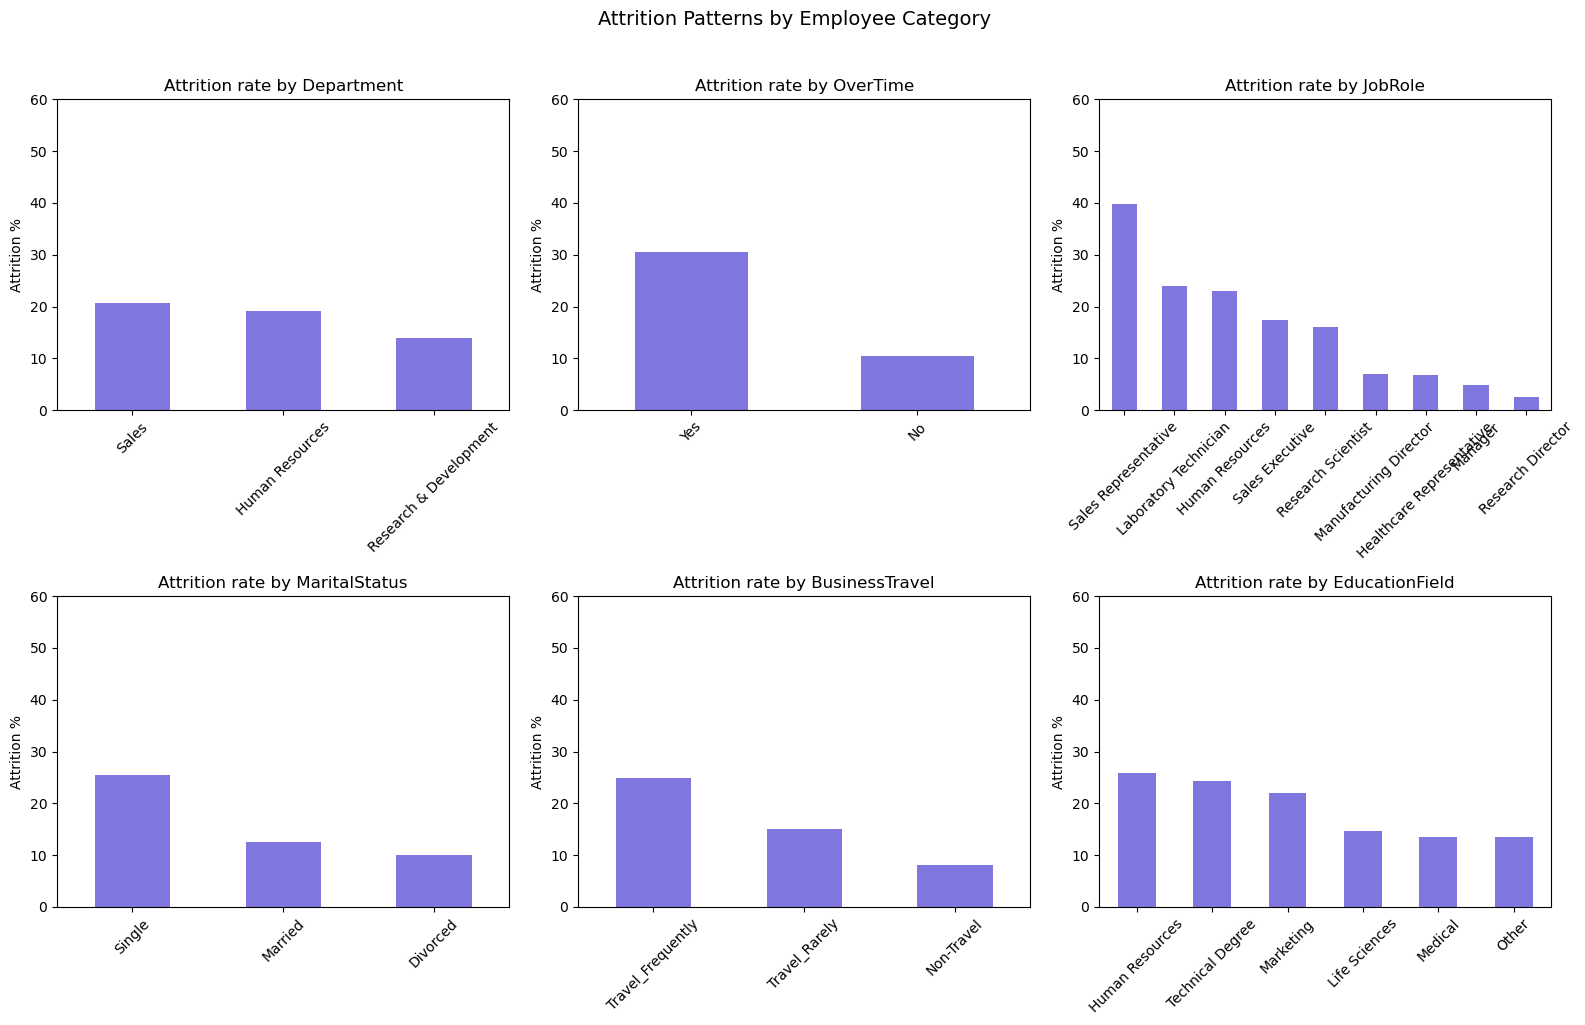

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

cols = ['Department', 'OverTime', 'JobRole', 
        'MaritalStatus', 'BusinessTravel', 'EducationField']

for i, col in enumerate(cols):
    ax = axes[i//3][i%3]
    attrition_rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x=='Yes').sum() / len(x) * 100
    ).sort_values(ascending=False)
    
    attrition_rate.plot(kind='bar', ax=ax, color='#7F77DD', edgecolor='none')
    ax.set_title(f'Attrition rate by {col}', fontsize=12)
    ax.set_ylabel('Attrition %')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 60)

plt.suptitle('Attrition Patterns by Employee Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('attrition_by_category.png', bbox_inches='tight', dpi=150)
plt.show()

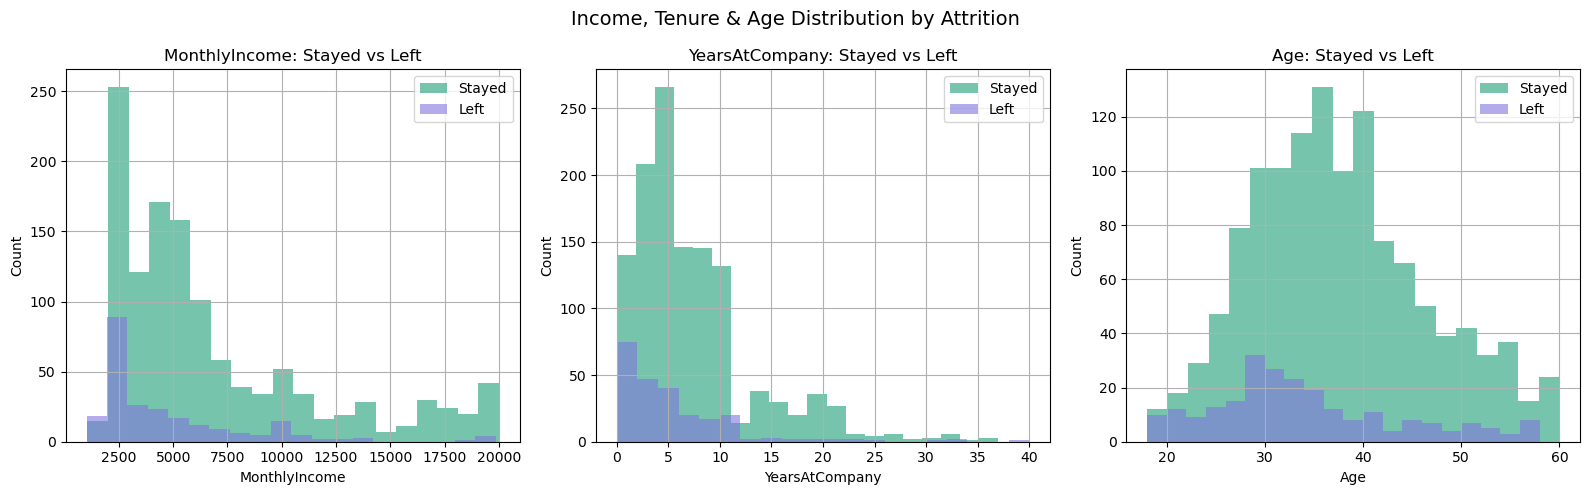

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

num_cols = ['MonthlyIncome', 'YearsAtCompany', 'Age']

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    df[df['Attrition']=='No'][col].hist(ax=ax, alpha=0.6, 
        color='#1D9E75', label='Stayed', bins=20, edgecolor='none')
    df[df['Attrition']=='Yes'][col].hist(ax=ax, alpha=0.6, 
        color='#7F77DD', label='Left', bins=20, edgecolor='none')
    
    ax.set_title(f'{col}: Stayed vs Left', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Income, Tenure & Age Distribution by Attrition', fontsize=14)
plt.tight_layout()
plt.savefig('attrition_numeric.png', bbox_inches='tight', dpi=150)
plt.show()

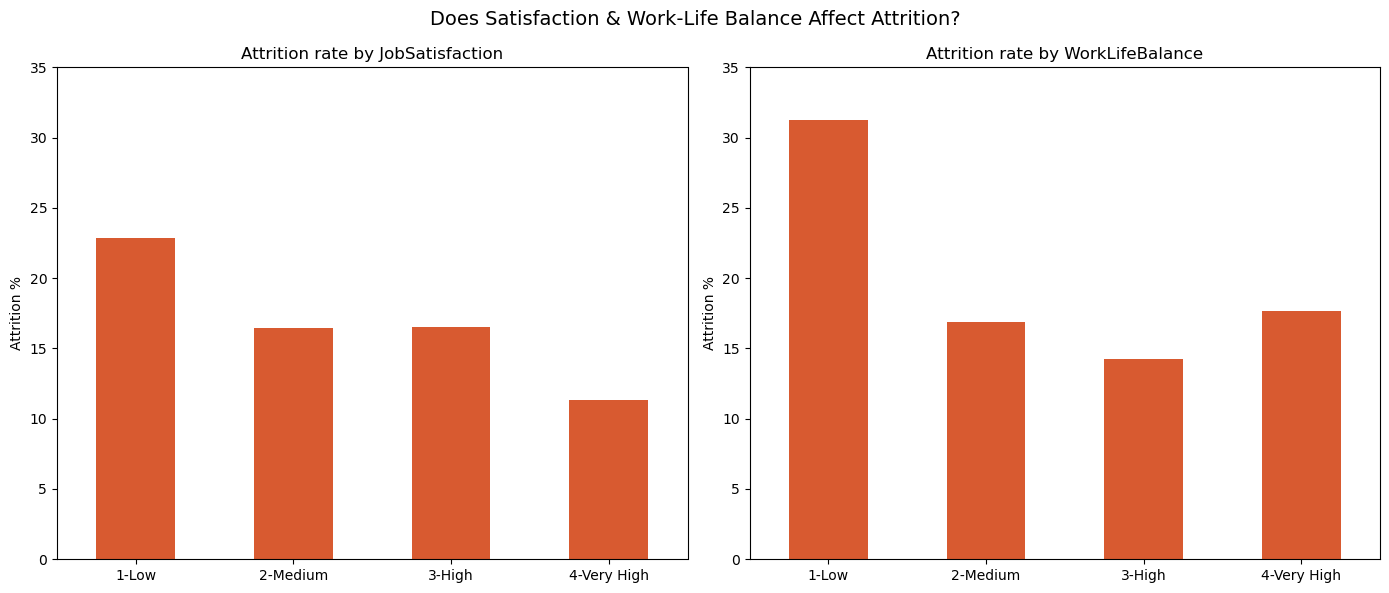

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

satisfaction_cols = ['JobSatisfaction', 'WorkLifeBalance']
labels = {1: '1-Low', 2: '2-Medium', 3: '3-High', 4: '4-Very High'}

for i, col in enumerate(satisfaction_cols):
    ax = axes[i]
    
    attrition_rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x=='Yes').sum() / len(x) * 100
    )
    
    attrition_rate.index = [labels[k] for k in attrition_rate.index]
    attrition_rate.plot(kind='bar', ax=ax, color='#D85A30', edgecolor='none')
    ax.set_title(f'Attrition rate by {col}', fontsize=12)
    ax.set_ylabel('Attrition %')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0, 35)

plt.suptitle('Does Satisfaction & Work-Life Balance Affect Attrition?', fontsize=14)
plt.tight_layout()
plt.savefig('attrition_satisfaction.png', bbox_inches='tight', dpi=150)
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

le = LabelEncoder()
text_cols = df_model.select_dtypes(include='object').columns

for col in text_cols:
    df_model[col] = le.fit_transform(df_model[col])

print(df_model.dtypes.value_counts())
print(df_model.head())

int64    35
Name: count, dtype: int64
   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EmployeeCount  EmployeeNumber  ...  \
0          2               1              1               1  ...   
1          1               1              1               2  ...   
2          2               4              1               4  ...   
3          4               1              1               5  ...   
4          1               3              1               7  ...   

   RelationshipSatisfaction  StandardHours  StockOptionLevel  \
0                   

In [10]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (1176, 34)
Testing set: (294, 34)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("LOGISTIC REGRESSION")
print(classification_report(y_train, lr.predict(X_train_scaled), 
      target_names=['Stayed', 'Left']))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

      Stayed       0.89      0.98      0.93       986
        Left       0.76      0.36      0.49       190

    accuracy                           0.88      1176
   macro avg       0.82      0.67      0.71      1176
weighted avg       0.87      0.88      0.86      1176



In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf, 
      target_names=['Stayed', 'Left']))

RANDOM FOREST
              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91       247
        Left       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294



In [13]:
from sklearn.metrics import classification_report

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_prob_rf >= 0.3).astype(int)

print("RANDOM FOREST — adjusted threshold (0.30)")
print(classification_report(y_test, y_pred_adjusted,
      target_names=['Stayed', 'Left']))

RANDOM FOREST — adjusted threshold (0.30)
              precision    recall  f1-score   support

      Stayed       0.87      0.92      0.90       247
        Left       0.42      0.30      0.35        47

    accuracy                           0.82       294
   macro avg       0.65      0.61      0.62       294
weighted avg       0.80      0.82      0.81       294



In [14]:
y_pred_adjusted2 = (y_prob_rf >= 0.2).astype(int)

print("RANDOM FOREST — adjusted threshold (0.20)")
print(classification_report(y_test, y_pred_adjusted2,
      target_names=['Stayed', 'Left']))

RANDOM FOREST — adjusted threshold (0.20)
              precision    recall  f1-score   support

      Stayed       0.93      0.80      0.86       247
        Left       0.39      0.66      0.49        47

    accuracy                           0.78       294
   macro avg       0.66      0.73      0.67       294
weighted avg       0.84      0.78      0.80       294



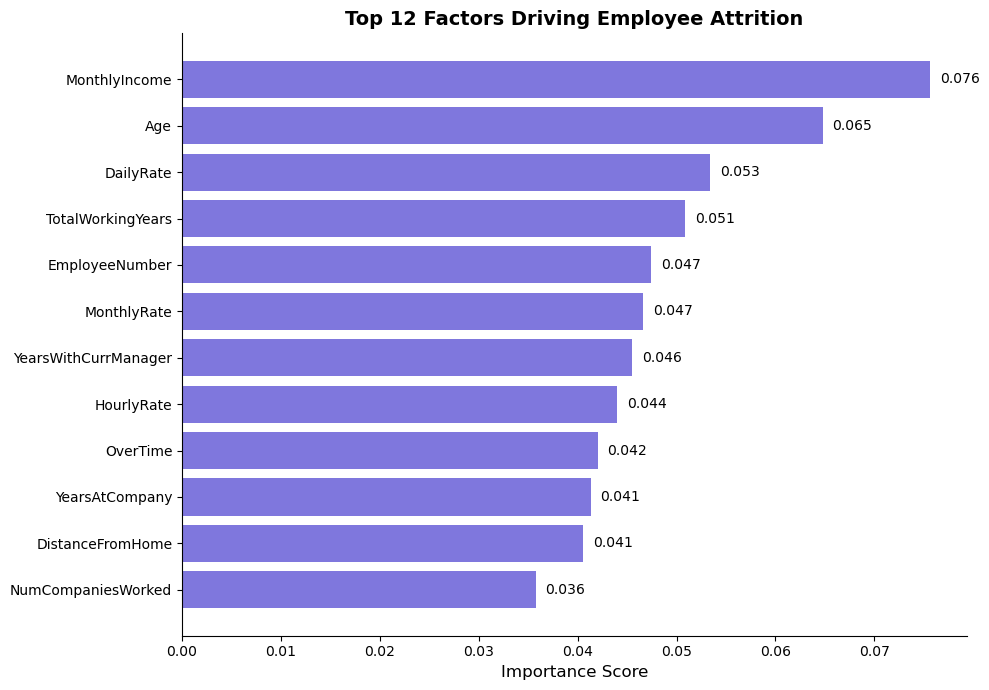

In [15]:
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(feat_importance['Feature'][::-1], 
               feat_importance['Importance'][::-1],
               color='#7F77DD', edgecolor='none')

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 12 Factors Driving Employee Attrition', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, feat_importance['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

In [16]:
X_clean = X.drop('EmployeeNumber', axis=1)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

rf_clean = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_clean.fit(X_train_c, y_train_c)

y_prob_clean = rf_clean.predict_proba(X_test_c)[:, 1]
y_pred_clean = (y_prob_clean >= 0.2).astype(int)

print("RANDOM FOREST — cleaned (EmployeeNumber removed)")
print(classification_report(y_test_c, y_pred_clean,
      target_names=['Stayed', 'Left']))

RANDOM FOREST — cleaned (EmployeeNumber removed)
              precision    recall  f1-score   support

      Stayed       0.92      0.79      0.85       247
        Left       0.36      0.62      0.46        47

    accuracy                           0.77       294
   macro avg       0.64      0.71      0.65       294
weighted avg       0.83      0.77      0.79       294



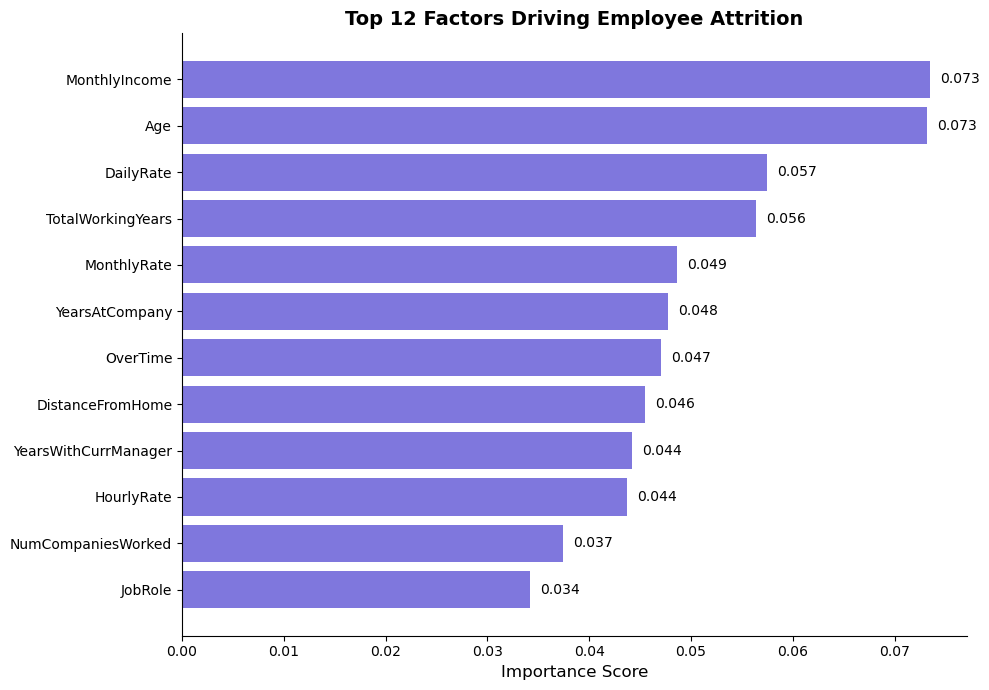

In [21]:
#I identified and removed a spurious variable (EmployeeNumber) that the model incorrectly flagged as significant

feat_importance_clean = pd.DataFrame({
    'Feature': X_clean.columns,
    'Importance': rf_clean.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(feat_importance_clean['Feature'][::-1], 
               feat_importance_clean['Importance'][::-1],
               color='#7F77DD', edgecolor='none')

ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 12 Factors Driving Employee Attrition', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, feat_importance_clean['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance_clean.png', bbox_inches='tight', dpi=150)
plt.show()

In [20]:
high_risk = X_test_c.copy()
high_risk['Attrition_Prob'] = y_prob_clean
high_risk['Predicted_Leaver'] = y_pred_clean
high_risk['MonthlyIncome'] = df.loc[X_test_c.index, 'MonthlyIncome']
high_risk['AnnualSalary'] = high_risk['MonthlyIncome'] * 12

predicted_leavers = high_risk[high_risk['Predicted_Leaver'] == 1]

replacement_cost = predicted_leavers['AnnualSalary'].sum() * 1.0

print(f"Predicted leavers in test set: {len(predicted_leavers)}")
print(f"Average annual salary of predicted leavers: ${predicted_leavers['AnnualSalary'].mean():,.0f}")
print(f"Estimated cost of attrition (test set): ${replacement_cost:,.0f}")

total_employees = len(df)
predicted_leaver_rate = len(predicted_leavers) / len(X_test_c)
estimated_annual_cost = df['MonthlyIncome'].mean() * 12 * predicted_leaver_rate * total_employees

print(f"\nEstimated company-wide annual attrition cost: ${estimated_annual_cost:,.0f}")
print(f"(Based on 100% of annual salary per leaver — SHRM benchmark)")

Predicted leavers in test set: 80
Average annual salary of predicted leavers: $44,704
Estimated cost of attrition (test set): $3,576,360

Estimated company-wide annual attrition cost: $31,214,070
(Based on 100% of annual salary per leaver — SHRM benchmark)
